In [180]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [181]:
df1=pd.read_csv("/btc_5years_binance.csv")
df2=pd.read_csv("/eth_5years_binance.csv")

In [182]:
df1.head()

,date,open,high,low,close,volume,quote_volume
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08


In [183]:
df2.head()

,date,open,high,low,close,volume,quote_volume
0,2020-03-22,132.63,137.13,121.10,122.32,1.055700e+06,1.359279e+08
1,2020-03-23,122.31,137.50,119.50,135.92,1.436796e+06,1.848516e+08
2,2020-03-24,135.89,143.36,132.20,138.42,1.244377e+06,1.711564e+08
3,2020-03-25,138.42,142.33,132.54,136.10,1.034249e+06,1.417953e+08
4,2020-03-26,136.11,139.74,133.26,138.40,7.510606e+05,1.019188e+08


In [184]:
df1["date"].value_counts()

,count
date,
2026-03-20,1
2020-03-22,1
2020-03-23,1
2020-03-24,1
2020-03-25,1
...,...
2020-04-09,1
2020-04-08,1
2020-04-07,1


In [185]:
df1["date"]=pd.to_datetime(df1['date'])
df1["year"]=df1['date'].dt.year

In [186]:
df1['year'].value_counts()

,count
year,
2024,366
2022,365
2021,365
2025,365
2023,365
2020,285
2026,79


In [187]:
df1=df1.drop(columns="year")

In [188]:
df1.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume'], dtype='object')

In [189]:
df1.isna().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0
quote_volume,0


In [190]:
df1.duplicated(subset='date').sum()

np.int64(0)

In [191]:
df2['date']=pd.to_datetime(df2['date'])

In [192]:
df2.duplicated(subset='date').sum()

np.int64(0)

In [193]:
df1["type"]='BTC'

In [194]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08,BTC
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09,BTC
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09,BTC
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08,BTC
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08,BTC


In [195]:
df2["type"]='ETH'

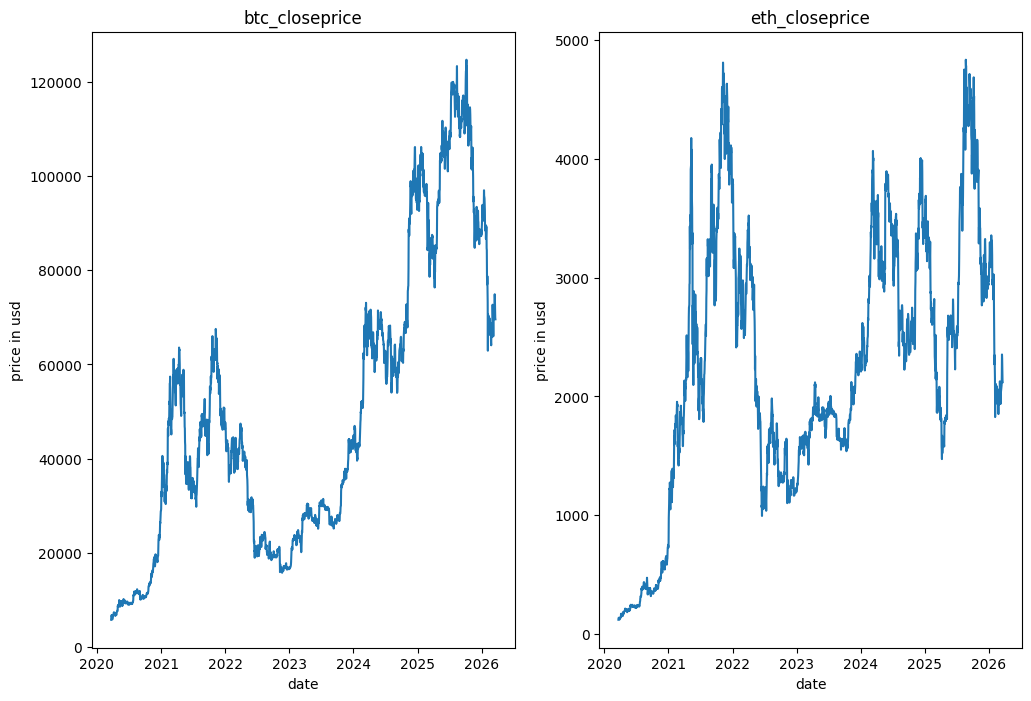

In [196]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.lineplot(x='date',data=df1,y='close')
plt.title("btc_closeprice")
plt.ylabel("price in usd")
plt.subplot(1,2,2)
sns.lineplot(x='date',data=df2,y='close')
plt.title("eth_closeprice")
plt.ylabel("price in usd")
plt.show()

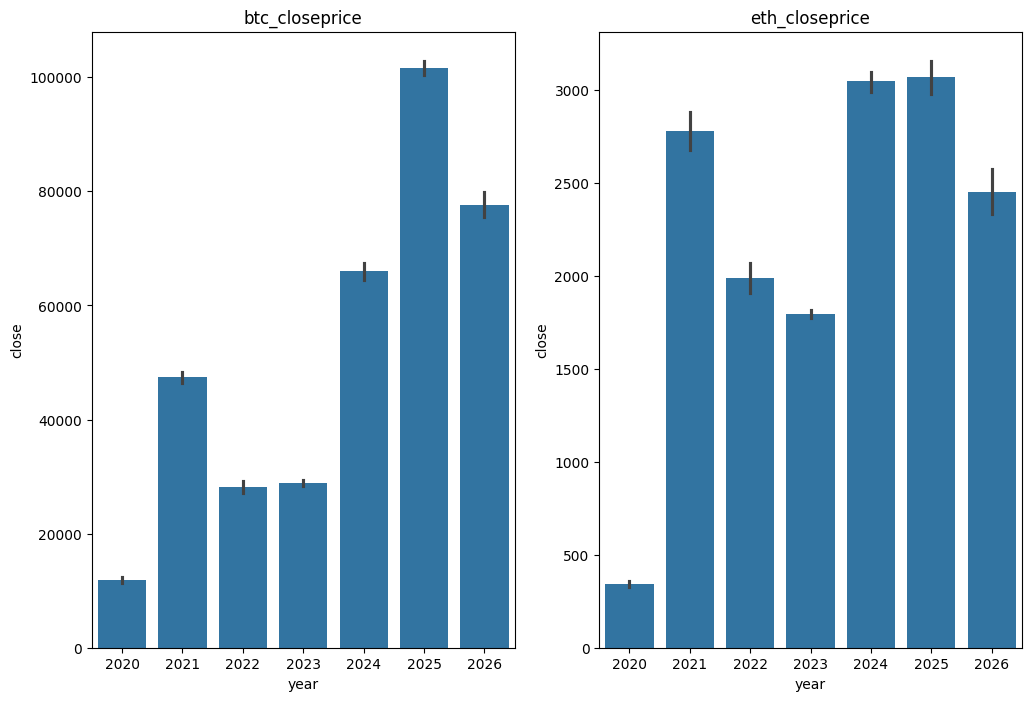

In [197]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
df1["year"]=df1["date"].dt.year
sns.barplot(x='year',data=df1,y='close')
plt.title("btc_closeprice")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=df2,y='close')
plt.title("eth_closeprice")
plt.show()

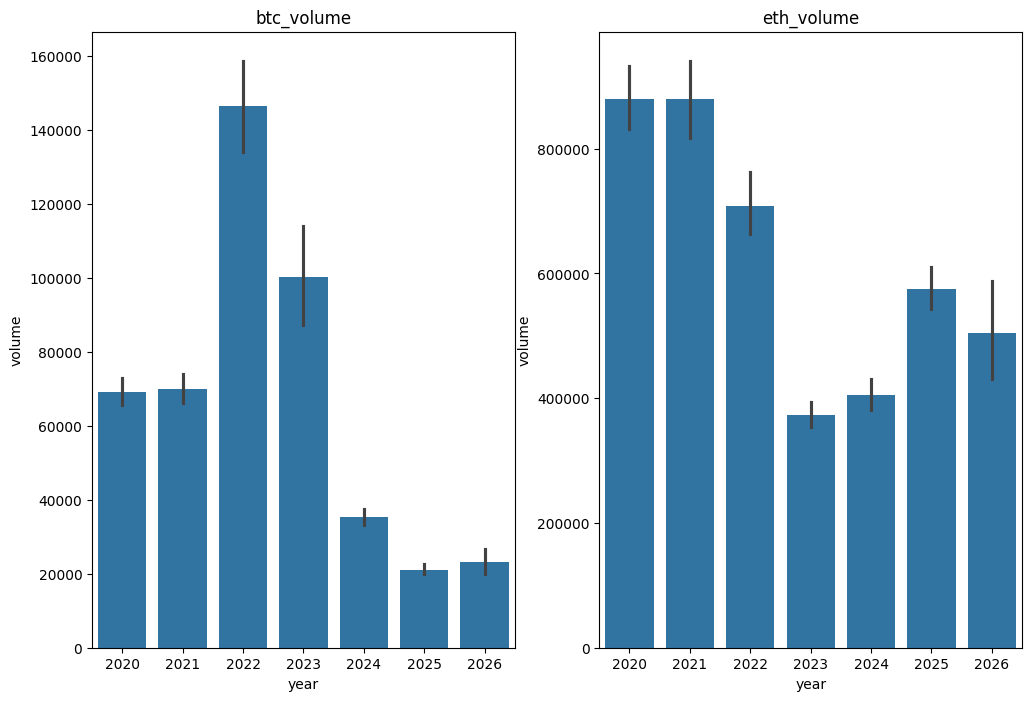

In [198]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
df1["year"]=df1["date"].dt.year
sns.barplot(x='year',data=df1,y='volume')
plt.title("btc_volume")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=df2,y='volume')
plt.title("eth_volume")
plt.show()

In [199]:
df1[['open','high','low','close','volume','quote_volume']].describe()

,open,high,low,close,volume,quote_volume
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2.190000e+03
mean,49684.851571,50706.157904,48588.060530,49713.850781,72041.067983,2.405291e+09
std,31059.051366,31510.559634,30557.274821,31048.027839,86914.767449,1.970179e+09
min,5816.050000,6266.000000,5688.000000,5816.190000,3104.117220,2.066281e+08
25%,24342.577500,25132.772500,23863.335000,24413.105000,24744.679520,1.091421e+09
50%,42547.145000,43405.365000,41629.205000,42561.935000,43615.005305,1.873282e+09
75%,67807.182500,68989.000000,66366.835000,67835.537500,77545.003452,3.023708e+09
max,124658.540000,126199.630000,123084.000000,124658.540000,760705.362783,1.746531e+10


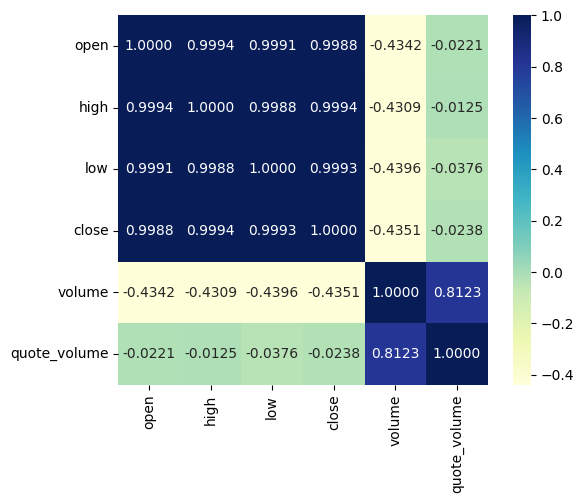

In [200]:
corr1=df1[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr1,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show() #as i predicted above the relation between volume and close price is negative as when volume is high thats mean closing price was low so alot of people buy

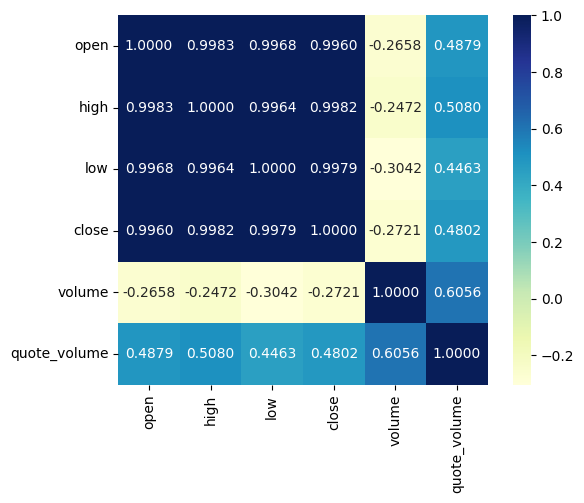

In [201]:
corr2=df2[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr2,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [202]:
for year in [2020, 2021, 2022, 2023, 2024,2025]:
    btc_year = df1[df1['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_year['date'],
        open=btc_year['open'],
        high=btc_year['high'],
        low=btc_year['low'],
        close=btc_year['close']
    )])

    fig.update_layout(title=f'BTC Candlestick Chart - {year}')
    fig.show()

In [203]:
import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    btc_filtered = df1[(df1['date'].dt.year == year) & (df1['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_filtered['date'],
        open=btc_filtered['open'],
        high=btc_filtered['high'],
        low=btc_filtered['low'],
        close=btc_filtered['close']
    )])

    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()

In [204]:
for year in [2020, 2021, 2022, 2023, 2024,2025]:
    eth_year = df2[df2['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=eth_year['date'],
        open=eth_year['open'],
        high=eth_year['high'],
        low=eth_year['low'],
        close=eth_year['close']
    )])

    fig.update_layout(title=f'ETH Candlestick Chart - {year}')
    fig.show()

In [205]:
import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    eth_filtered = df2[(df2['date'].dt.year == year) & (df2['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=eth_filtered['date'],
        open=eth_filtered['open'],
        high=eth_filtered['high'],
        low=eth_filtered['low'],
        close=eth_filtered['close']
    )])

    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()

In [206]:
df1.drop(columns='year',inplace=True)
df2.drop(columns='year',inplace=True)

## Feature engeering

In [207]:
df1["candle_body"]=df1['close']-df1['open']
df2['candle_body']=df2['close']-df2['open']


In [208]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08,BTC,-370.85
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09,BTC,651.26
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09,BTC,279.47
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08,BTC,-67.26
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08,BTC,59.94


In [209]:
df1['high_low_range']=df1['high']-df1['low']
df2['high_low_range']=df2['high']-df2['low']

In [210]:
df1['MA_7']=df1['close'].rolling(window=7).mean()
df2['MA_7']=df2['close'].rolling(window=7).mean()

In [211]:
df1['MA_30']=df1['close'].rolling(window=30).mean()
df2['MA_30']=df2['close'].rolling(window=30).mean()

In [212]:
df1['moving_1d']=(df1['close']-df1['close'].shift(1))/df1['close'].shift(1) * 100
df2['moving_1d']=(df2['close']-df2['close'].shift(1))/df2['close'].shift(1) * 100

In [213]:
df1["volatility_7"] = df1["moving_1d"].rolling(window=7).std()
df2["volatility_7"] = df2["moving_1d"].rolling(window=7).std()

In [214]:
df1["volume_MA7"] = df1["volume"].rolling(window=7).mean()
df1["volumelast7"] = df1["volume"] / df1["volume_MA7"]
df2["volume_MA7"] = df2["volume"].rolling(window=7).mean()
df2["volumelast7"] = df2["volume"] / df2["volume_MA7"]

In [215]:
df1.drop(columns='volume_MA7',inplace=True)
df2.drop(columns='volume_MA7',inplace=True)

In [216]:
df1["rolling_mean_30"] = df1["close"].rolling(window=30).mean()
df1["rolling_std_30"]  = df1["close"].rolling(window=30).std()
df1["z_score"] = (df1["close"] - df1["rolling_mean_30"]) / df1["rolling_std_30"]

df2["rolling_mean_30"] = df2["close"].rolling(window=30).mean()
df2["rolling_std_30"]  = df2["close"].rolling(window=30).std()
df2["z_score"] = (df2["close"] - df2["rolling_mean_30"]) / df2["rolling_std_30"]

In [217]:
df1.drop(columns='rolling_mean_30',inplace=True)
df2.drop(columns='rolling_mean_30',inplace=True)
df1.drop(columns='rolling_std_30',inplace=True)
df2.drop(columns='rolling_std_30',inplace=True)

In [218]:
df1['tomorrow_close'] = df1['close'].shift(-1)
df1['tomorrow_return'] = (df1['tomorrow_close'] - df1['close']) / df1['close'] * 100


df2['tomorrow_close'] = df2['close'].shift(-1)
df2['tomorrow_return'] = (df2['tomorrow_close'] - df2['close']) / df2['close'] * 100

In [219]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08,BTC,-370.85,673.86,NaN,NaN,NaN,NaN,NaN,NaN,6467.31,11.194958
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09,BTC,651.26,912.00,NaN,NaN,11.194958,NaN,NaN,NaN,6744.72,4.289419
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09,BTC,279.47,461.67,NaN,NaN,4.289419,NaN,NaN,NaN,6677.43,-0.997669
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08,BTC,-67.26,507.96,NaN,NaN,-0.997669,NaN,NaN,NaN,6737.36,0.897501
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08,BTC,59.94,270.00,NaN,NaN,0.897501,NaN,NaN,NaN,6359.11,-5.614217


In [220]:
from scipy.stats import skew, kurtosis
df1 = df1.dropna(subset=['tomorrow_return'])
skew2=skew(df1['tomorrow_return'])
print(skew2)

df2 = df2.dropna(subset=['tomorrow_return'])
skew21=skew(df2['tomorrow_return'])
print(skew21)

kurtosis1=kurtosis(df1['tomorrow_return'])
kurtosis2=kurtosis(df2['tomorrow_return'])
kurtosis1,kurtosis2

0.1922848540029284
0.24096026170188115


(np.float64(3.6680023751096256), np.float64(4.498956387626494))

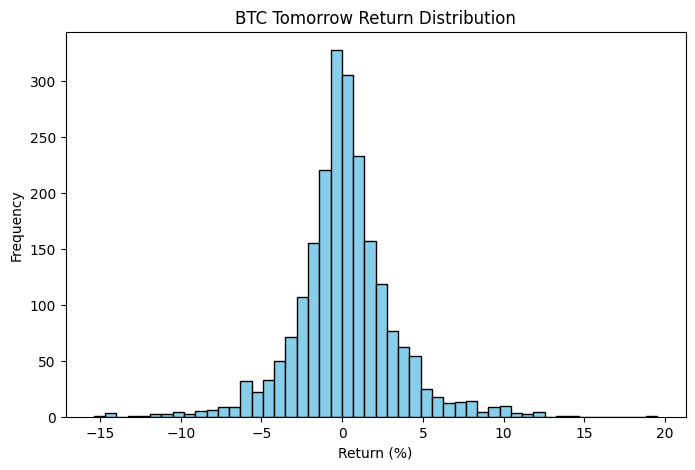

In [221]:
import matplotlib.pyplot as plt

# Example for BTC
plt.figure(figsize=(8,5))
plt.hist(df1['tomorrow_return'], bins=50, color='skyblue', edgecolor='black')
plt.title('BTC Tomorrow Return Distribution')
plt.xlabel('Return (%)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_179/4186346857.py:4: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




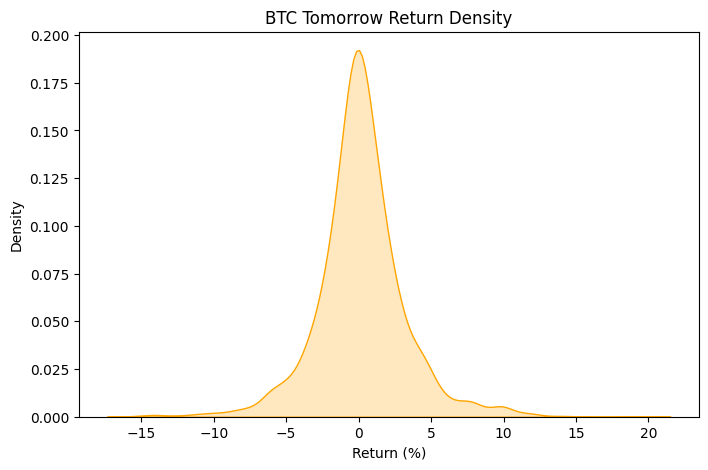

In [222]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df1['tomorrow_return'], shade=True, color='orange')
plt.title('BTC Tomorrow Return Density')
plt.xlabel('Return (%)')
plt.show()

/tmp/ipykernel_179/2788286287.py:7: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




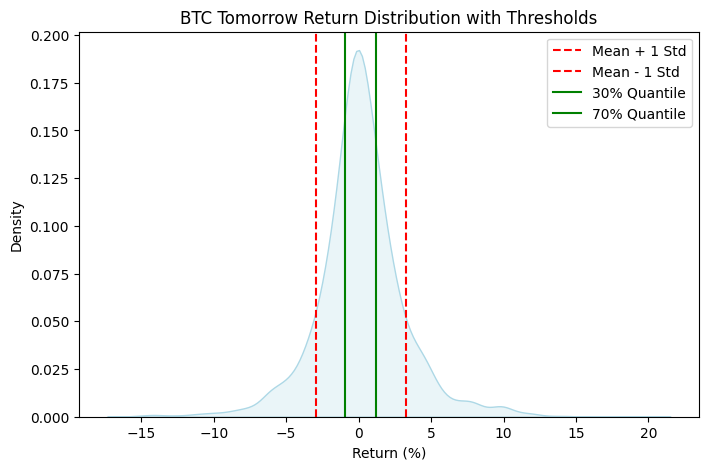

In [223]:
mean = df1['tomorrow_return'].mean()
std = df1['tomorrow_return'].std()
q_low = df1['tomorrow_return'].quantile(0.3)
q_high = df1['tomorrow_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(df1['tomorrow_return'], shade=True, color='lightblue')

# Mean ± std thresholds
plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

# Quantile thresholds
plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('BTC Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

/tmp/ipykernel_179/542878942.py:7: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




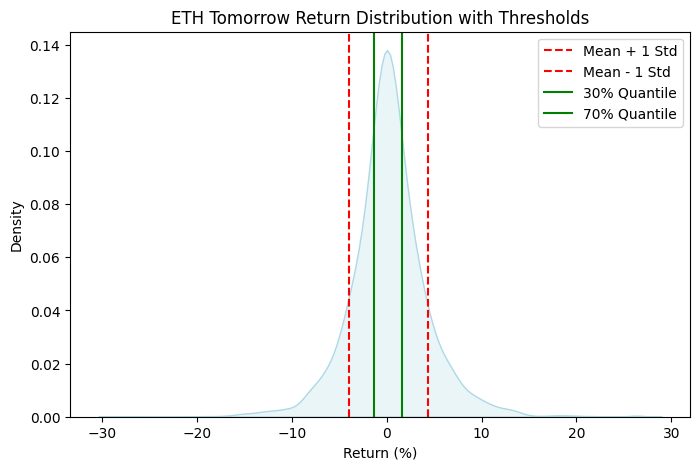

In [224]:
mean = df2['tomorrow_return'].mean()
std = df2['tomorrow_return'].std()
q_low = df2['tomorrow_return'].quantile(0.3)
q_high = df2['tomorrow_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(df2['tomorrow_return'], shade=True, color='lightblue')

# Mean ± std thresholds
plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

# Quantile thresholds
plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('ETH Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

In [225]:
df1.drop(columns='tomorrow_close',inplace=True)
df1.drop(columns='tomorrow_return',inplace=True)
df2.drop(columns='tomorrow_close',inplace=True)
df2.drop(columns='tomorrow_return',inplace=True)

In [226]:
df1[30:35]

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score
30,2020-04-21,6828.98,6940.00,6762.00,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445
31,2020-04-22,6841.36,7156.38,6818.00,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536
32,2020-04-23,7125.12,7738.00,7020.00,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948
33,2020-04-24,7483.96,7615.96,7388.00,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384
34,2020-04-25,7505.00,7705.00,7431.07,7538.67,43874.427726,3.312921e+08,BTC,33.67,273.93,7205.734286,6901.351333,0.448634,3.169357,0.661556,1.616816


In [227]:
df1.isna().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0
quote_volume,0
type,0
candle_body,0
high_low_range,0


In [228]:
df1.dropna(inplace=True)
df2.dropna(inplace=True)

In [229]:
df1.reset_index(drop=True,inplace=True)
df2.reset_index(drop=True,inplace=True)

In [230]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score
0,2020-04-20,7121.40,7220.00,6751.0,6826.83,90149.491370,6.296124e+08,BTC,-294.57,469.00,6973.657143,6766.366000,-4.127520,4.021079,1.274637,0.157665
1,2020-04-21,6828.98,6940.00,6762.0,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445
2,2020-04-22,6841.36,7156.38,6818.0,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536
3,2020-04-23,7125.12,7738.00,7020.0,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948
4,2020-04-24,7483.96,7615.96,7388.0,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384


In [231]:
print(df2.shape) ## both of them was 2190 originally
print(df1.shape)

(2160, 16)
(2160, 16)


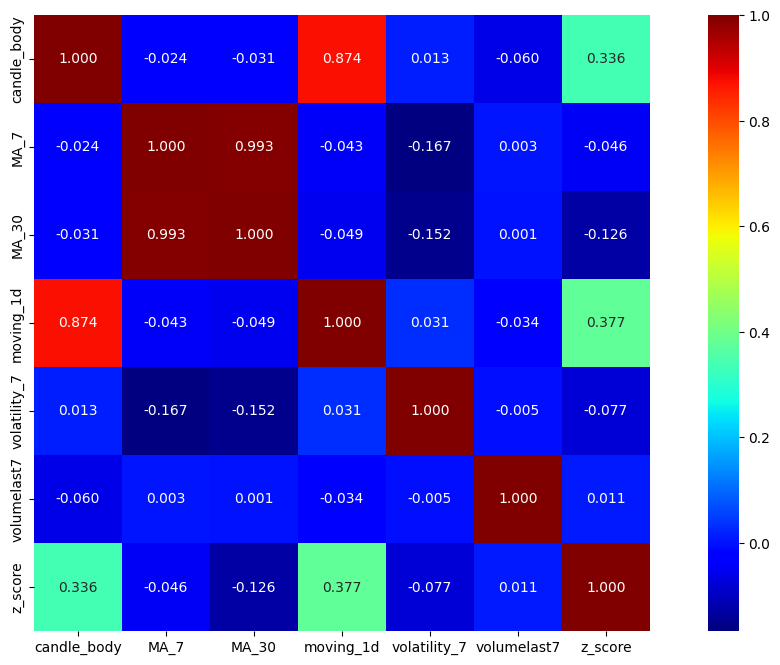

In [232]:
plt.figure(figsize=(15,8))
corr8=df1[['candle_body','MA_7','MA_30','moving_1d','volatility_7','volumelast7','z_score']].corr()
sns.heatmap(corr8,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

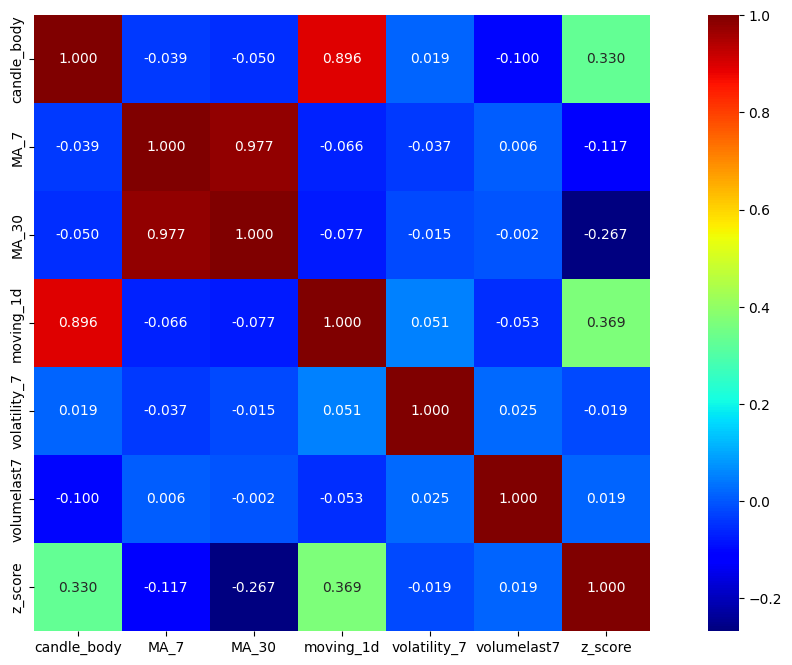

In [233]:
plt.figure(figsize=(15,8))
corr9=df2[['candle_body','MA_7','MA_30','moving_1d','volatility_7','volumelast7','z_score']].corr()
sns.heatmap(corr9,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

In [234]:
combined=pd.concat([df1,df2],ignore_index=True)
combined.to_csv("eth_btc_data.csv",index=False)

In [235]:
df3=pd.read_csv("eth_btc_data.csv")

In [236]:
df3['trend'] = df3['MA_7'] - df3['MA_30']

In [237]:
df3.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,trend
0,2020-04-20,7121.40,7220.00,6751.0,6826.83,90149.491370,6.296124e+08,BTC,-294.57,469.00,6973.657143,6766.366000,-4.127520,4.021079,1.274637,0.157665,207.291143
1,2020-04-21,6828.98,6940.00,6762.0,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445,169.214190
2,2020-04-22,6841.36,7156.38,6818.0,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536,219.272238
3,2020-04-23,7125.12,7738.00,7020.0,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948,249.033238
4,2020-04-24,7483.96,7615.96,7388.0,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384,289.654714


# **BNB_SOL**

In [238]:
df4 = pd.read_csv('/bnb_6years_binance.csv')
df4.head(3)

,date,open,high,low,close,volume,quote_volume
0,2020-03-25,12.4261,12.7108,12.0561,12.3251,3607793.89,4.449144e+07
1,2020-03-26,12.3253,13.2565,12.1900,13.1990,3439169.72,4.290229e+07
2,2020-03-27,13.1989,13.3655,12.1600,12.3354,2778050.91,3.608494e+07


In [239]:
df5 = pd.read_csv('/sol_6years_binance.csv')
df5.head(3)

,date,open,high,low,close,volume,quote_volume
0,2020-08-11,2.8500,3.5208,2.8433,3.2985,1552384.78,4.939149e+06
1,2020-08-12,3.2985,3.9289,3.0800,3.7558,1737042.95,6.176154e+06
2,2020-08-13,3.7500,4.1387,3.5003,3.7300,1685759.24,6.446568e+06


In [240]:
df4['type'] = 'BNB'
df5['type'] = 'SOL'

In [241]:
df4.head(1)

,date,open,high,low,close,volume,quote_volume,type
0,2020-03-25,12.4261,12.7108,12.0561,12.3251,3607793.89,4.449144e+07,BNB


In [242]:
df5.head(1)

,date,open,high,low,close,volume,quote_volume,type
0,2020-08-11,2.85,3.5208,2.8433,3.2985,1552384.78,4.939149e+06,SOL


In [243]:
df4.isna().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0
quote_volume,0
type,0


In [244]:
df5.isna().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0
quote_volume,0
type,0


In [245]:
print(df4['date'].value_counts())
print("duplicates:")
df4.duplicated(subset='date').sum()

date
2026-03-23    1
2020-03-25    1
2020-03-26    1
2020-03-27    1
2020-03-28    1
             ..
2020-04-12    1
2020-04-11    1
2020-04-10    1
2020-04-09    1
2020-04-08    1
Name: count, Length: 2190, dtype: int64
duplicates:


np.int64(0)

In [246]:
print(df5['date'].value_counts())
print("duplicates:")
df5.duplicated(subset='date').sum()

date
2026-03-23    1
2020-08-11    1
2020-08-12    1
2026-03-07    1
2026-03-06    1
             ..
2020-08-18    1
2020-08-17    1
2020-08-16    1
2020-08-15    1
2020-08-14    1
Name: count, Length: 2051, dtype: int64
duplicates:


np.int64(0)

In [247]:
df4['date']=pd.to_datetime(df4['date'])
df4['year']=df4['date'].dt.year
df4['year'].value_counts()

,count
year,
2024,366
2022,365
2021,365
2025,365
2023,365
2020,282
2026,82


In [248]:
df5['date']=pd.to_datetime(df5['date'])
df5['year']=df5['date'].dt.year
df5['year'].value_counts()

,count
year,
2024,366
2022,365
2021,365
2025,365
2023,365
2020,143
2026,82


In [249]:
df4.drop(columns='year',inplace=True)
df5.drop(columns='year',inplace=True)

In [250]:
df4.duplicated(subset='date').sum()

np.int64(0)

In [251]:
df5.duplicated(subset='date').sum()

np.int64(0)

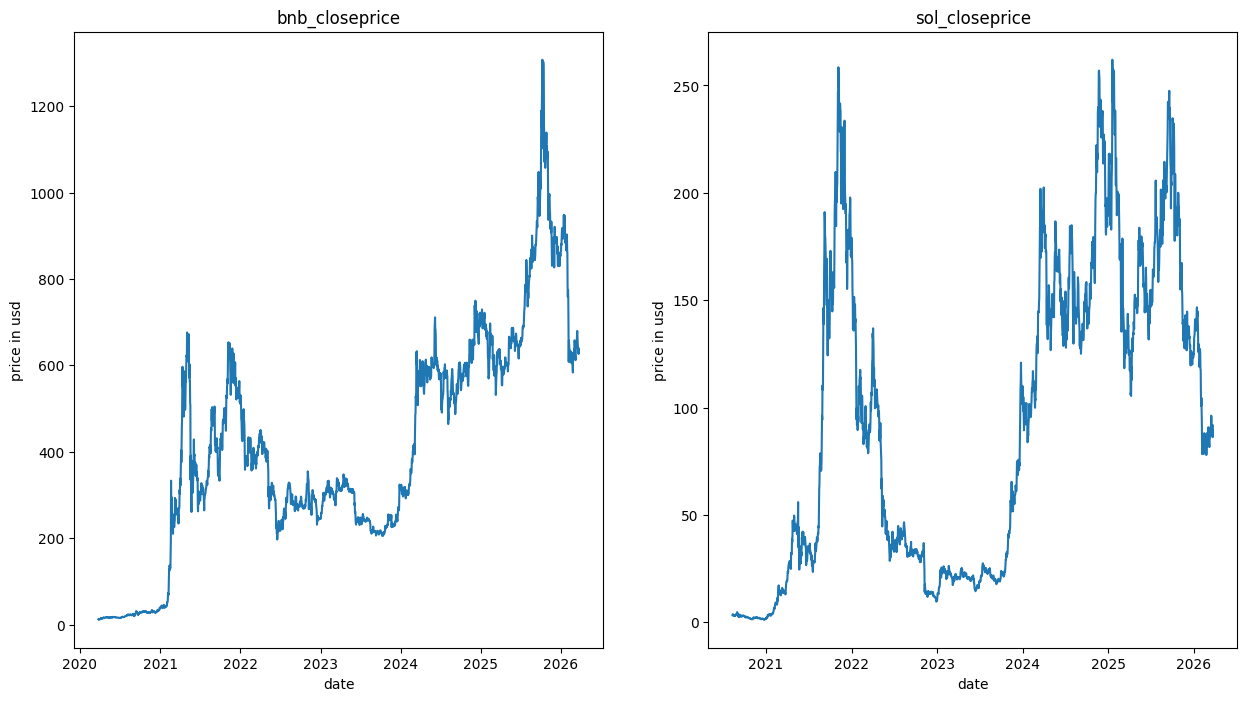

In [252]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
sns.lineplot(x='date',data=df4,y='close')
plt.title("bnb_closeprice")
plt.ylabel("price in usd")
plt.subplot(1,2,2)
sns.lineplot(x='date',data=df5,y='close')
plt.title("sol_closeprice")
plt.ylabel("price in usd")
plt.show()

/tmp/ipykernel_179/2521454798.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_179/2521454798.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




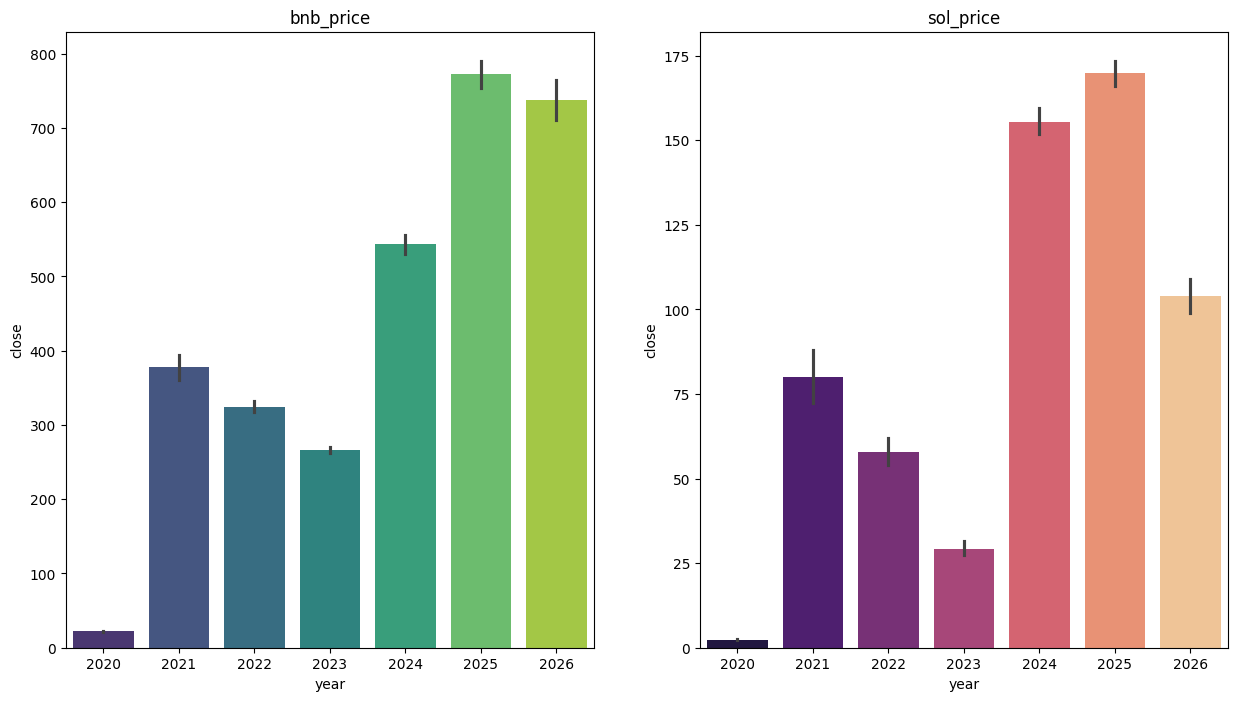

In [253]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
df4['year']=df4['date'].dt.year
sns.barplot(x='year',data=df4,y='close', palette = 'viridis')
plt.title("bnb_price")
plt.subplot(1,2,2)
df5['year']=df5['date'].dt.year
sns.barplot(x='year',data=df5,y='close', palette = 'magma')
plt.title("sol_price")
plt.show()

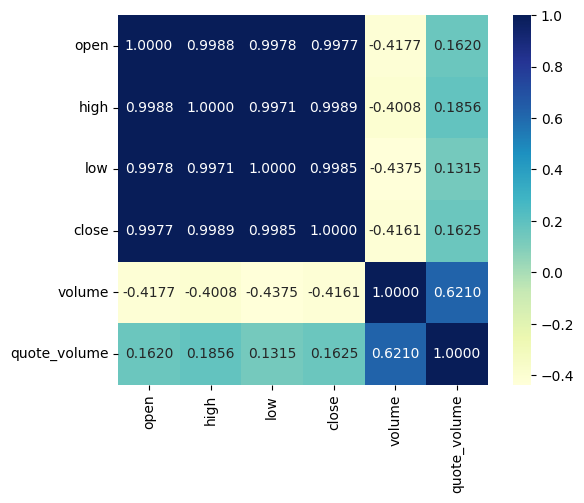

In [254]:
corr4=df4[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr4,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

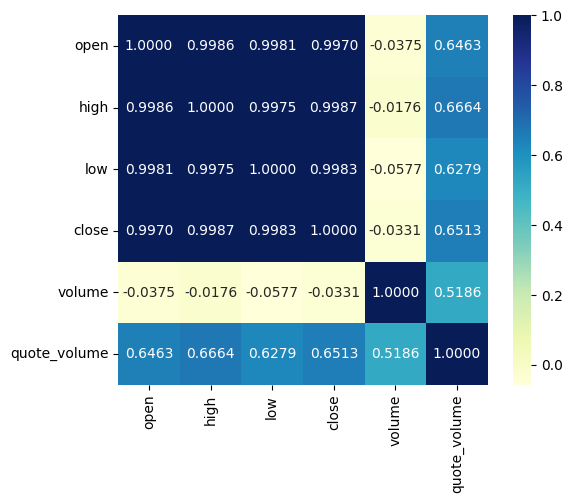

In [255]:
corr5=df5[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr5,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [256]:
for year in [2020, 2021, 2022, 2023, 2024,2025]:
    bnb_year = df4[df4['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x = bnb_year['date'],
        open = bnb_year['open'],
        high = bnb_year['high'],
        low = bnb_year['low'],
        close = bnb_year['close']
    )])

    fig.update_layout(title=f'BNB Candlestick Chart - {year}')
    fig.show()

In [257]:
for year in [2020, 2021, 2022, 2023, 2024,2025]:
    sol_year = df5[df5['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x = sol_year['date'],
        open = sol_year['open'],
        high = sol_year['high'],
        low = sol_year['low'],
        close = sol_year['close']
    )])

    fig.update_layout(title=f'SOL Candlestick Chart - {year}')
    fig.show()

In [258]:
df4['candle_body']=df4['close']-df4['open']
df5['candle_body']=df5['close']-df5['open']

df4['high_low_range']=df4['high']-df4['low']
df5['high_low_range']=df5['high']-df5['low']

In [259]:
df4['MA_7']=df4['close'].rolling(window=7).mean()
df5['MA_7']=df5['close'].rolling(window=7).mean()

df4['MA_30']=df4['close'].rolling(window=30).mean()
df5['MA_30']=df5['close'].rolling(window=30).mean()

In [260]:
df4['moving_1d']=(df4['close']-df4['close'].shift(1))/df4['close'].shift(1) * 100
df5['moving_1d']=(df5['close']-df5['close'].shift(1))/df5['close'].shift(1) * 100

In [261]:
df4["volatility_7"] = df4["moving_1d"].rolling(window=7).std()
df5["volatility_7"] = df5["moving_1d"].rolling(window=7).std()

In [262]:
df4["volume_MA7"] = df4["volume"].rolling(window=7).mean()
df4["volumelast7"] = df4["volume"] / df4["volume_MA7"]
df5["volume_MA7"] = df5["volume"].rolling(window=7).mean()
df5["volumelast7"] = df5["volume"] / df5["volume_MA7"]

In [263]:
df4["rolling_mean_30"] = df4["close"].rolling(window=30).mean()
df4["rolling_std_30"]  = df4["close"].rolling(window=30).std()
df4["z_score"] = (df4["close"] - df4["rolling_mean_30"]) / df4["rolling_std_30"]

In [264]:
df5["rolling_mean_30"] = df5["close"].rolling(window=30).mean()
df5["rolling_std_30"]  = df5["close"].rolling(window=30).std()
df5["z_score"] = (df5["close"] - df5["rolling_mean_30"]) / df5["rolling_std_30"]

In [265]:
df4.drop(columns='volume_MA7',inplace=True)
df4.drop(columns='rolling_mean_30',inplace=True)
df4.drop(columns='rolling_std_30',inplace=True)
df5.drop(columns='volume_MA7',inplace=True)
df5.drop(columns='rolling_mean_30',inplace=True)
df5.drop(columns='rolling_std_30',inplace=True)

In [266]:
df4['tomorrow_close'] = df4['close'].shift(-1)
df4['tomorrow_return'] = (df4['tomorrow_close'] - df4['close']) / df4['close'] * 100

df4.head(3)

,date,open,high,low,close,volume,quote_volume,type,year,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-03-25,12.4261,12.7108,12.0561,12.3251,3607793.89,4.449144e+07,BNB,2020,-0.1010,0.6547,NaN,NaN,NaN,NaN,NaN,NaN,13.1990,7.090409
1,2020-03-26,12.3253,13.2565,12.1900,13.1990,3439169.72,4.290229e+07,BNB,2020,0.8737,1.0665,NaN,NaN,7.090409,NaN,NaN,NaN,12.3354,-6.542920
2,2020-03-27,13.1989,13.3655,12.1600,12.3354,2778050.91,3.608494e+07,BNB,2020,-0.8635,1.2055,NaN,NaN,-6.542920,NaN,NaN,NaN,12.1888,-1.188450


In [267]:
df5['tomorrow_close'] = df5['close'].shift(-1)
df5['tomorrow_return'] = (df5['tomorrow_close'] - df5['close']) / df5['close'] * 100

df5.head(3)

,date,open,high,low,close,volume,quote_volume,type,year,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-08-11,2.8500,3.5208,2.8433,3.2985,1552384.78,4.939149e+06,SOL,2020,0.4485,0.6775,NaN,NaN,NaN,NaN,NaN,NaN,3.7558,13.863878
1,2020-08-12,3.2985,3.9289,3.0800,3.7558,1737042.95,6.176154e+06,SOL,2020,0.4573,0.8489,NaN,NaN,13.863878,NaN,NaN,NaN,3.7300,-0.686938
2,2020-08-13,3.7500,4.1387,3.5003,3.7300,1685759.24,6.446568e+06,SOL,2020,-0.0200,0.6384,NaN,NaN,-0.686938,NaN,NaN,NaN,3.4099,-8.581769
